In [ ]:
import pandas as pd
s=pd.Series([2,-1,3,5])
print(s)

0    2
1   -1
2    3
3    5
dtype: int64


In [ ]:
import pandas as pd

s2 = pd.Series(
    [68,83,112,68],
    index=["Alice","Bob","Charles","Darwin"]
)
print(s2)
print()
print(s2["Bob"])
print()
print(s2[1])

Alice       68
Bob         83
Charles    112
Darwin      68
dtype: int64

83

83


/tmp/ipykernel_1553/4256427517.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(s2[1])


In [ ]:
result = s<0
print(result)

0    False
1     True
2    False
3    False
dtype: bool


In [ ]:
print(result.iloc[1])
print(s2.loc["Bob"])
print(s2.iloc[2])

True
83
112


In [ ]:
weights={"Alice":68 , "Bob":83 ,"Colin":86}
s3=pd.Series(weights)
print(s3)

Alice    68
Bob      83
Colin    86
dtype: int64


In [ ]:
print(s2)
print(s3)
print()
print(s2+s3)#automatic alignment


Alice       68
Bob         83
Charles    112
Darwin      68
dtype: int64
Alice    68
Bob      83
Colin    86
dtype: int64

Alice      136.0
Bob        166.0
Charles      NaN
Colin        NaN
Darwin       NaN
dtype: float64


In [ ]:
meaning=pd.Series(42,["life" ,"Universe","everything"])
print(meaning)

life          42
Universe      42
everything    42
dtype: int64


In [ ]:
import pandas as pd

people_dict = {
    "weight": pd.Series(
        [68, 83, 112],
        index=["alice", "bob", "charles"]
    ),

    "birthyear": pd.Series(
        [1984, 1985, 1992],
        index=["bob", "alice", "charles"],
        name="year"
    ),

    "children": pd.Series(
        [3],
        index=["bob"]
    ),

    "hobby": pd.Series(
        ["Biking", "Dancing"],
        index=["alice", "bob"]
    ),
}

people =pd.DataFrame(people_dict)
print(people)
print()
print(people["weight"])
print()
print(people["hobby"])
print()



         weight  birthyear  children    hobby
alice        68       1985       NaN   Biking
bob          83       1984       3.0  Dancing
charles     112       1992       NaN      NaN

alice       68
bob         83
charles    112
Name: weight, dtype: int64

alice       Biking
bob        Dancing
charles        NaN
Name: hobby, dtype: object



In [ ]:
print(people[["birthyear","hobby"]])
print()
print(people.loc["charles"])
print()
print(people.iloc[1:3])

         birthyear    hobby
alice         1985   Biking
bob           1984  Dancing
charles       1992      NaN

weight        112
birthyear    1992
children      NaN
hobby         NaN
Name: charles, dtype: object

         weight  birthyear  children    hobby
bob          83       1984       3.0  Dancing
charles     112       1992       NaN      NaN


In [ ]:
people["Age"]=2016-people["birthyear"]
people["Over 30"] =people["Age"]>30
print(people)

         weight  birthyear  children    hobby  Age  Over 30
alice        68       1985       NaN   Biking   31     True
bob          83       1984       3.0  Dancing   32     True
charles     112       1992       NaN      NaN   24    False


In [ ]:
del people["height"]
people.insert(1,"height",[172,181,185])
print(people)

         weight  height  birthyear  children    hobby  Age  Over 30
alice        68     172       1985       NaN   Biking   31     True
bob          83     181       1984       3.0  Dancing   32     True
charles     112     185       1992       NaN      NaN   24    False


In [ ]:
people.assign(body_mass_index = lambda df:df["weight"]/df["height"]/100 **2).assign(overweihgt = lambda df:df["body_mass_index"]>25)

,weight,height,birthyear,children,hobby,Age,Over 30,body_mass_index,overweihgt
alice,68,172,1985,NaN,Biking,31,True,0.000040,False
bob,83,181,1984,3.0,Dancing,32,True,0.000046,False
charles,112,185,1992,NaN,NaN,24,False,0.000061,False


In [ ]:
people.sort_index(ascending =False)

,weight,height,birthyear,children,hobby,Age,Over 30
charles,112,185,1992,NaN,NaN,24,False
bob,83,181,1984,3.0,Dancing,32,True
alice,68,172,1985,NaN,Biking,31,True


In [ ]:
people.loc["eugene"] = {
    "weight": 75,
    "birthyear": 1990,
    "children": 1,
    "hobby": "Reading"
}
print(people)

# insert a new people using dictionary

         weight  height  birthyear  children    hobby   Age Over 30
alice        68   172.0       1985       NaN   Biking  31.0     1.0
bob          83   181.0       1984       3.0  Dancing  32.0     1.0
charles     112   185.0       1992       NaN      NaN  24.0     0.0
eugene       75     NaN       1990       1.0  Reading   NaN     NaN


In [ ]:
people.sort_values(by="Age", inplace=True)
print(people)

         weight  height  birthyear  children    hobby   Age Over 30
charles     112   185.0       1992       NaN      NaN  24.0     0.0
alice        68   172.0       1985       NaN   Biking  31.0     1.0
bob          83   181.0       1984       3.0  Dancing  32.0     1.0
eugene       75     NaN       1990       1.0  Reading   NaN     NaN


<Axes: xlabel='Age'>

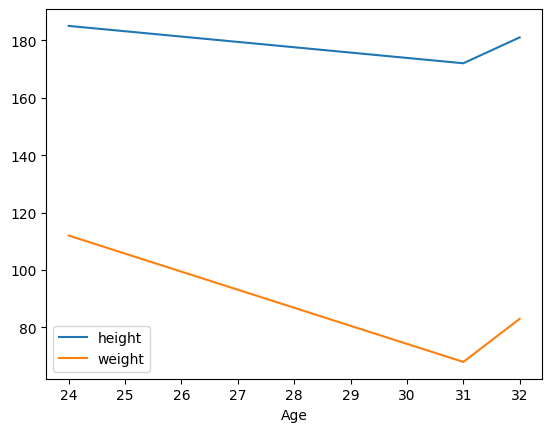

In [ ]:
import matplotlib.pyplot as plt
people.plot(kind="line", x="Age", y=["height" ,"weight"])


In [ ]:
## Machine Learning ENcoding Methods
# Hot Shot Technique
import pandas as pd

data = {'Color': ['Red', 'Blue', 'Green', 'Blue','Yellow','Black']}

df = pd.DataFrame(data)

df_encoded = pd.get_dummies(df, columns=['Color'], prefix='Color')

print(df_encoded)

   Color_Black  Color_Blue  Color_Green  Color_Red  Color_Yellow
0        False       False        False       True         False
1        False        True        False      False         False
2        False       False         True      False         False
3        False        True        False      False         False
4        False       False        False      False          True
5         True       False        False      False         False


In [ ]:
#Binning Method for Categorizing data
import pandas as pd

data = {'Age': [23, 45, 18, 34, 67, 50, 21]}

df = pd.DataFrame(data)

bins = [0, 20, 40, 60, 100]

labels = ['0-20', '21-40', '41-60', '61+']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

print(df)

   Age Age_Group
0   23     21-40
1   45     41-60
2   18      0-20
3   34     21-40
4   67       61+
5   50     41-60
6   21     21-40


In [ ]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer

# Run once if stopwords are not downloaded
# nltk.download('stopwords')

texts = [
    "This is a sample sentence.",
    "Text data preprocessing is important."
]

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    # Convert to lowercase and remove punctuation
    words = re.findall(r'\b[a-zA-Z]+\b', text.lower())

    # Remove stopwords and apply stemming
    words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

# Preprocess all texts
cleaned_texts = [preprocess_text(text) for text in texts]

# Vectorize
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(cleaned_texts)

print("Cleaned Texts:")
print(cleaned_texts)

print("\nVocabulary:")
print(vectorizer.get_feature_names_out())

print("\nVectorized Text:")
print(X.toarray())

LookupError: 
**********************************************************************
  Resource [93mstopwords[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('stopwords')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mcorpora/stopwords[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************
